# AI-Driven Student Performance Prediction System

## A Machine Learning Project

### Submitted By

**Name:** Deeksha Jaiswal 

**Course:** B.Tech (CSE)

**Semester:** 5th

**Roll No.:** 2403841530006

**Subject:** Artificial Intelligence

**Submission Date:** 01 August 2026

---

## Department of Computer Science & Engineering

### Academic Session: 2026

# Introduction

Student performance prediction is one of the important applications of Machine Learning. It helps educational institutions analyze students' academic performance and identify students who may need additional support. In this project, a Linear Regression model is used to predict the final grade (G3) of students based on different academic and personal factors. The project demonstrates the complete Machine Learning process, including data preprocessing, visualization, model training, prediction, and evaluation.

# Objective

- To predict the final grade (G3) of students using Machine Learning.
- To analyze the factors affecting student performance.
- To preprocess and visualize the dataset.
- To train and evaluate a Linear Regression model.
- To compare the actual and predicted grades.

# Dataset Used

**Dataset Name:** Student Performance Dataset

**Source:** UCI Machine Learning Repository

**File Used:** student-por.csv (or student-mat.csv, whichever you used)

**Target Variable:** G3 (Final Grade)

The dataset contains student information such as gender, age, study time, failures, absences, health, G1, G2, and G3. These features are used to predict the final academic performance of students.

# Import Libraries

The required Python libraries are imported for data analysis, visualization, preprocessing, model training, and evaluation.

# Load Dataset

The dataset is loaded into a Pandas DataFrame using the `read_csv()` function. This allows us to analyze and process the data efficiently.

# Dataset Exploration

Before building the machine learning model, the dataset is explored using functions like `head()`, `shape`, `info()`, `describe()`, and `isnull()`. This helps us understand the structure, data types, and overall quality of the dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
import pandas as pd

df = pd.read_csv("Downloads/archive/student-por.csv")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-null    str  
 21  inte

In [4]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [5]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [6]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='str')

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.head()

C:\Users\Dell\AppData\Local\Temp\ipykernel_8400\3405490672.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,0,0,18,1,0,0,4,4,0,4,...,4,3,4,1,1,3,4,0,11,11
1,0,0,17,1,0,1,1,1,0,2,...,5,3,3,1,1,3,2,9,11,11
2,0,0,15,1,1,1,1,1,0,2,...,4,3,2,2,3,3,6,12,13,12
3,0,0,15,1,0,1,4,2,1,3,...,3,2,2,1,1,5,0,14,14,14
4,0,0,16,1,0,1,3,3,2,2,...,4,3,2,1,2,5,0,11,13,13


In [8]:
X = df.drop("G3", axis=1)
y = df["G3"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(519, 32)
(130, 32)


In [9]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [10]:
y_pred = model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 0.7554213592640455
MSE: 1.4370937042409988
R2 Score: 0.852631710385228


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

In [11]:
comparison = pd.DataFrame({
    "Actual Grade": y_test,
    "Predicted Grade": y_pred
})

comparison.head(10)

,Actual Grade,Predicted Grade
636,19,18.146496
220,12,11.683475
594,18,18.251362
429,11,10.917185
72,11,11.792849
448,17,16.295027
181,18,17.376929
131,8,9.082122
231,10,10.975502
277,11,10.547356


# Data Visualization

Data visualization helps in understanding the distribution of student grades and the relationship between different features. Various graphs are created to analyze student performance visually.

# Data Preprocessing

Machine Learning algorithms require numerical input. Therefore, categorical features are converted into numerical values using Label Encoding. The data is then divided into training and testing sets for model development.

# Model Building

A Linear Regression model is selected for predicting the final grade (G3). The model is trained using the training dataset and then tested on unseen data.

# Prediction

After training the model, predictions are generated for the test dataset. These predicted values are compared with the actual grades to evaluate the model's performance.

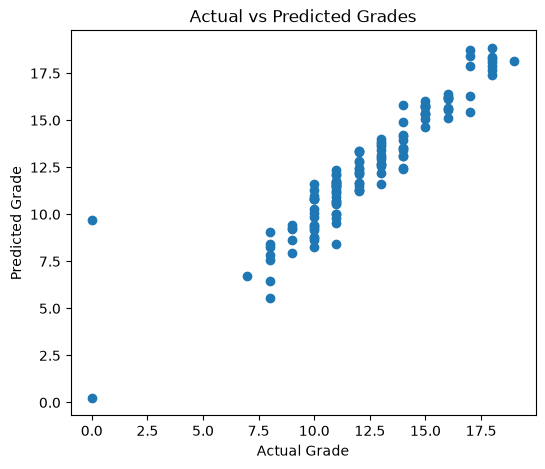

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Grade")
plt.ylabel("Predicted Grade")
plt.title("Actual vs Predicted Grades")

plt.show()

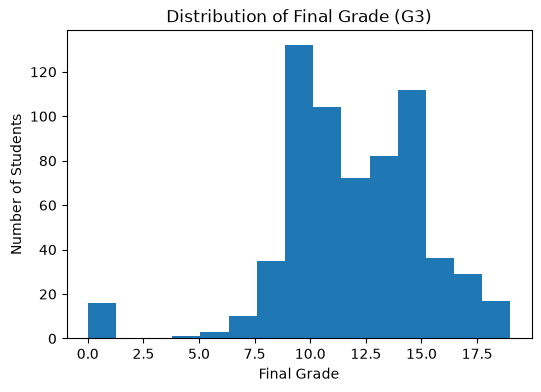

In [13]:
plt.figure(figsize=(6,4))

plt.hist(df["G3"], bins=15)

plt.title("Distribution of Final Grade (G3)")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")

plt.show()

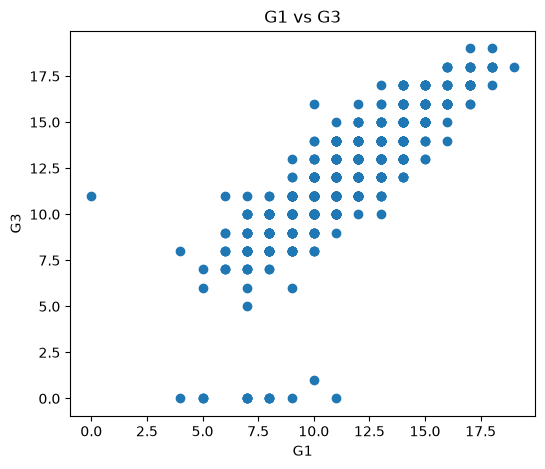

In [14]:
plt.figure(figsize=(6,5))

plt.scatter(df["G1"], df["G3"])

plt.xlabel("G1")
plt.ylabel("G3")

plt.title("G1 vs G3")

plt.show()

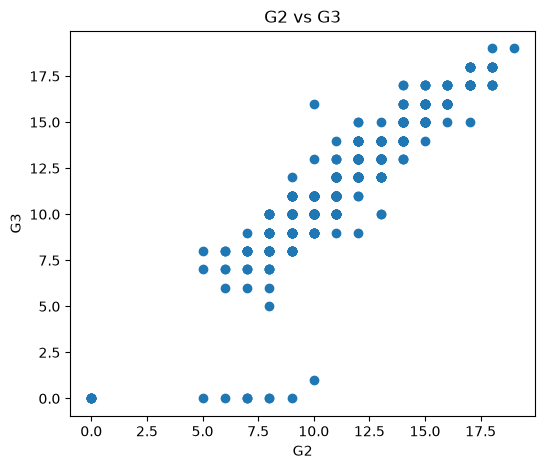

In [15]:
plt.figure(figsize=(6,5))

plt.scatter(df["G2"], df["G3"])

plt.xlabel("G2")
plt.ylabel("G3")

plt.title("G2 vs G3")

plt.show()

### Graph: Study Time vs Final Grade

This graph shows the relationship between students' study time and their average final grade (G3). It helps understand whether increased study time is associated with better academic performance.

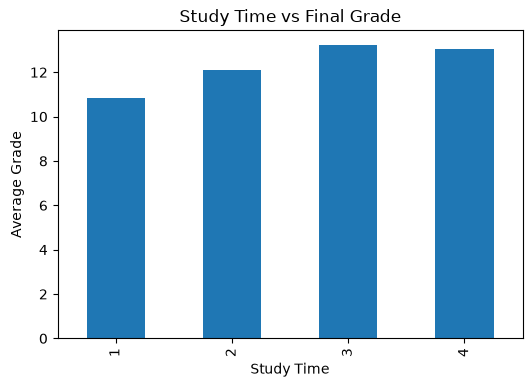

In [16]:
plt.figure(figsize=(6,4))

df.groupby("studytime")["G3"].mean().plot(kind="bar")

plt.title("Study Time vs Final Grade")

plt.xlabel("Study Time")

plt.ylabel("Average Grade")

plt.show()

plt.figure(figsize=(6,4))

df.groupby("failures")["G3"].mean().plot(kind="bar")

plt.title("Failures vs Final Grade")

plt.xlabel("Failures")

plt.ylabel("Average Grade")

plt.show()

# Model Evaluation

The performance of the Linear Regression model is evaluated using three metrics:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R2 Score

These metrics help measure how accurately the model predicts the final student grades.

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_pred))
print("Root Mean Squared Error (RMSE):", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Absolute Error (MAE): 0.7554213592640455
Root Mean Squared Error (RMSE): 1.1987884318097997
R2 Score: 0.852631710385228


# Result

The Linear Regression model was successfully trained using the student performance dataset.

The model predicted the final grade (G3) with satisfactory accuracy.

The comparison between actual and predicted values shows that the model performs well on unseen data.

The obtained results indicate that previous academic performance has a strong impact on the final grade.

# Conclusion

This project successfully demonstrates the use of Machine Learning to predict student performance. A Linear Regression model was trained using the Student Performance dataset. Before training the model, the data was cleaned and categorical values were converted into numerical form. Different visualizations were also created to understand the relationship between various factors and the final grade.

The model was evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score. The obtained results show that the model can predict student performance with good accuracy. The comparison between actual and predicted values indicates that previous academic performance has a strong influence on the final grade.

This project helped in understanding the complete Machine Learning workflow, including data preprocessing, visualization, model training, prediction, and evaluation. In the future, more advanced algorithms such as Random Forest or XGBoost can be used to improve prediction accuracy.

# Future Scope

- Use a larger dataset to improve prediction accuracy.
- Apply advanced Machine Learning algorithms such as Random Forest and XGBoost.
- Develop a web application for real-time student performance prediction.
- Include more features such as attendance, extracurricular activities, and family background.
- Integrate the system with school management software.

# References

1. UCI Machine Learning Repository - Student Performance Dataset
2. Scikit-learn Documentation
3. Pandas Documentation
4. Matplotlib Documentation
5. Python Official Documentation

# Thank You

Thank you for reviewing my project.

This project helped me understand the complete Machine Learning workflow, including data preprocessing, visualization, model training, prediction, and evaluation.